In [ ]:
from google.colab import files

uploaded = files.upload()

Saving PROYECTO_QUÍMICA_ORGÁNICA_corregido.xlsx to PROYECTO_QUÍMICA_ORGÁNICA_corregido (3).xlsx


In [ ]:
pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
xls = pd.ExcelFile("/content/PROYECTO_QUÍMICA_ORGÁNICA_corregido.xlsx")
print(xls.sheet_names)

['Hoja 1']


Número de filas antes de filtrar: 301
Número de filas después de filtrar para 'hidrólisis' en la columna 'REACCIONES': 83


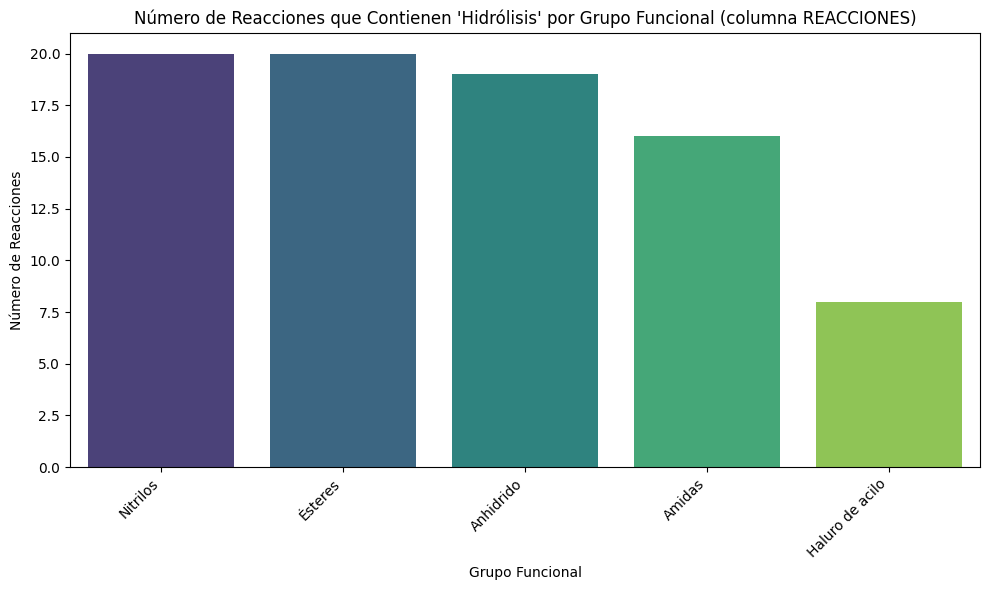

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the 'Hoja 1' sheet into a DataFrame named hidrolisis_reactions
hidrolisis_reactions = pd.read_excel("/content/PROYECTO_QUÍMICA_ORGÁNICA_corregido.xlsx", sheet_name='Hoja 1')

# --- Filtrar para incluir solo las reacciones de hidrólisis de la columna 'REACCIONES' ---
print(f"Número de filas antes de filtrar: {len(hidrolisis_reactions)}")
# Filtramos la columna 'REACCIONES' para cualquier cadena que contenga 'hidrólisis' (ignorando mayúsculas/minúsculas)
hidrolisis_reactions = hidrolisis_reactions[hidrolisis_reactions['REACCIONES'].str.contains('hidrólisis', case=False, na=False)].copy()
print(f"Número de filas después de filtrar para 'hidrólisis' en la columna 'REACCIONES': {len(hidrolisis_reactions)}")

if hidrolisis_reactions.empty:
    print("Advertencia: Después de filtrar, el DataFrame de hidrólisis está vacío. Por favor, verifica que la columna 'REACCIONES' contenga la palabra 'hidrólisis'.")

# Calculate hidrolisis_counts
hidrolisis_counts = hidrolisis_reactions['GRUPO FUNCIONAL'].value_counts().reset_index()
hidrolisis_counts.columns = ['GRUPO FUNCIONAL', 'Count']

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='GRUPO FUNCIONAL', y='Count', data=hidrolisis_counts, palette='viridis', hue='GRUPO FUNCIONAL', legend=False)
plt.title('Número de Reacciones que Contienen \'Hidrólisis\' por Grupo Funcional (columna REACCIONES)')
plt.xlabel('Grupo Funcional')
plt.ylabel('Número de Reacciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis Detallado del Punto de Ebullición de Productos de Reacciones de Hidrólisis

Vamos a analizar los puntos de ebullición de los productos resultantes de las reacciones de hidrólisis, segmentados por su grupo funcional. Para garantizar la precisión, primero inspeccionaremos los datos brutos de la columna de punto de ebullición para detectar cualquier entrada no numérica que pueda afectar la concordancia con los valores de medición en °C.

In [ ]:
import numpy as np

# Identificar la columna del punto de ebullición (columna 16, índice 15)
boiling_point_column = df.columns[15]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_df_copy = hidrolisis_reactions.copy()

print(f"Columna identificada para el punto de ebullición: '{boiling_point_column}'")

# --- Inspeccionar valores no numéricos antes de la conversión ---
# Intentar convertir a numérico y guardar los errores
non_numeric_values = pd.to_numeric(hidrolisis_df_copy[boiling_point_column], errors='coerce').isna()
problematic_entries = hidrolisis_df_copy[non_numeric_values & hidrolisis_df_copy[boiling_point_column].notna()][boiling_point_column].unique()

if len(problematic_entries) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas únicas en la columna de punto de ebullición (que serán convertidas a NaN):")
    for entry in problematic_entries:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas problemáticas en la columna de punto de ebullición.")

# Convertir la columna del punto de ebullición a tipo numérico, forzando errores a NaN
hidrolisis_df_copy[boiling_point_column] = pd.to_numeric(
    hidrolisis_df_copy[boiling_point_column], errors='coerce'
)

# Eliminar filas donde el punto de ebullición es NaN (es decir, no se pudo convertir o era un valor no numérico)
initial_rows = len(hidrolisis_df_copy)
hidrolisis_df_copy.dropna(subset=[boiling_point_column], inplace=True)
removed_rows = initial_rows - len(hidrolisis_df_copy)

if removed_rows > 0:
    print(f"\nSe eliminaron {removed_rows} filas debido a valores de punto de ebullición nulos o no convertibles.")
else:
    print("\nNo se eliminaron filas por valores nulos en el punto de ebullición.")

# Mostrar estadísticas descriptivas del punto de ebullición por grupo funcional
print("\nEstadísticas Descriptivas del Punto de Ebullición por Grupo Funcional (Productos de Hidrólisis):")
display(hidrolisis_df_copy.groupby('GRUPO FUNCIONAL')[boiling_point_column].describe())


NameError: name 'df' is not defined

### Gráfica Interactiva y Precisa del Punto de Ebullición por Grupo Funcional

Esta es una versión interactiva y más precisa del box plot. Podrás ver cada punto de dato individual y, al pasar el ratón por encima, obtendrás detalles como el ID del compuesto y el valor exacto del punto de ebullición, lo que te permitirá verificar la concordancia con las mediciones en °C.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express
# Incluimos `points='all'` para mostrar todos los puntos de datos y `hover_data` para detalles adicionales.
fig = px.box(
    hidrolisis_df_copy,
    x='GRUPO FUNCIONAL',
    y=boiling_point_column,
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del Punto de Ebullición de Productos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', boiling_point_column: 'Punto de Ebullición (°C)'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_df_copy['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', boiling_point_column] # Datos adicionales al pasar el ratón
)

fig.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Punto de Ebullición (°C)')
fig.show()

### Análisis Detallado del Punto de Ebullición de Sustratos de Reacciones de Hidrólisis

Vamos a analizar los puntos de ebullición de los sustratos (`Unnamed: 13`) involucrados en las reacciones de hidrólisis, segmentados por su grupo funcional. Primero, inspeccionaremos los datos brutos para detectar cualquier entrada no numérica o con formatos especiales (como rangos o incertidumbres) que necesite ser limpiada.

In [ ]:
import numpy as np

# Identificar la columna del punto de ebullición para sustratos (columna 14, índice 13)
boiling_point_substrate_column = hidrolisis_reactions.columns[13]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_substrato_df = hidrolisis_reactions.copy()

print(f"Columna identificada para el punto de ebullición de sustratos: '{boiling_point_substrate_column}'")

# Función robusta para parsear puntos de ebullición, manejando rangos, incertezas y formatos europeos/americanos
def parse_boiling_point_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±)
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '152-155') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            return (lower + upper) / 2
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        return float(value_str)
    except ValueError:
        return np.nan

# Aplicar la función de parsing a la columna de punto de ebullición de sustratos
hidrolisis_substrato_df['BOILING_POINT_SUBSTRATE_CLEANED'] = hidrolisis_substrato_df[boiling_point_substrate_column].apply(parse_boiling_point_robustly)

# --- Inspeccionar valores no numéricos antes de la conversión ---
problematic_entries_substrate = hidrolisis_substrato_df[
hidrolisis_substrato_df[boiling_point_substrate_column].notna() &
    hidrolisis_substrato_df['BOILING_POINT_SUBSTRATE_CLEANED'].isna()
][boiling_point_substrate_column].unique()

if len(problematic_entries_substrate) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas únicas en la columna de punto de ebullición de sustratos (que serán convertidas a NaN):")
    for entry in problematic_entries_substrate:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas problemáticas en la columna de punto de ebullición de sustratos.")

# Eliminar filas donde el punto de ebullición del sustrato es NaN (después del cleaning)
initial_rows_substrate = len(hidrolisis_substrato_df)
hidrolisis_substrato_df.dropna(subset=['BOILING_POINT_SUBSTRATE_CLEANED'], inplace=True)
removed_rows_substrate = initial_rows_substrate - len(hidrolisis_substrato_df)

if removed_rows_substrate > 0:
    print(f"\nSe eliminaron {removed_rows_substrate} filas debido a valores de punto de ebullición de sustrato nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el punto de ebullición de sustrato después de la limpieza.")

# Mostrar estadísticas descriptivas del punto de ebullición del sustrato por grupo funcional
print("\nEstadísticas Descriptivas del Punto de Ebullición de Sustratos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_substrato_df.groupby('GRUPO FUNCIONAL')['BOILING_POINT_SUBSTRATE_CLEANED'].describe())

### Gráfica Interactiva del Punto de Ebullición de Sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los puntos de ebullición de los sustratos, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el punto de ebullición de sustratos
fig_substrate_bp = px.box(
    hidrolisis_substrato_df,
    x='GRUPO FUNCIONAL',
    y='BOILING_POINT_SUBSTRATE_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del Punto de Ebullición de Sustratos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'BOILING_POINT_SUBSTRATE_CLEANED': 'Punto de Ebullición (°C) de Sustrato'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_substrato_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'REACTIVO 1', 'REACTIVO 2', 'BOILING_POINT_SUBSTRATE_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_substrate_bp.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Punto de Ebullición (°C) de Sustrato')
fig_substrate_bp.show()

### Análisis Detallado del Peso Molecular de Sustratos de Reacciones de Hidrólisis

Vamos a analizar el peso molecular de los sustratos involucrados en las reacciones de hidrólisis, segmentados por su grupo funcional. Para garantizar la precisión, primero inspeccionaremos los datos brutos de la columna de peso molecular para detectar cualquier entrada no numérica o con formatos especiales (como rangos o incertidumbres) que necesite ser limpiada.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna del peso molecular (columna 13, índice 12)
molecular_weight_substrate_column = hidrolisis_reactions.columns[12]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_mw_substrate_df = hidrolisis_reactions.copy()

print(f"Columna identificada para el peso molecular de sustratos: '{molecular_weight_substrate_column}'")

# Función robusta para parsear valores de peso molecular
def parse_molecular_weight_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND' or value == 'NA' or value == 'No disponible':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±)
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '152-155') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            # Sanity check for molecular weight values (must be positive)
            if lower > 0 and upper > 0:
                return (lower + upper) / 2
            else:
                return np.nan
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        num_value = float(value_str)
        # Sanity check for molecular weight values (must be positive)
        if num_value > 0:
            return num_value
        else:
            return np.nan
    except ValueError:
        return np.nan

# Aplicar la función de parsing a la columna de peso molecular de sustratos
hidrolisis_mw_substrate_df['PESO_MOLECULAR_SUBSTRATE_CLEANED'] = hidrolisis_mw_substrate_df[molecular_weight_substrate_column].apply(parse_molecular_weight_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_mw_substrate = hidrolisis_mw_substrate_df[
    hidrolisis_mw_substrate_df[molecular_weight_substrate_column].notna() &
    hidrolisis_mw_substrate_df['PESO_MOLECULAR_SUBSTRATE_CLEANED'].isna()
][molecular_weight_substrate_column].unique()

if len(problematic_entries_mw_substrate) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de peso molecular de sustratos (que serán convertidas a NaN):")
    for entry in problematic_entries_mw_substrate:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de peso molecular de sustratos.")

# Eliminar filas donde el peso molecular del sustrato es NaN (después del cleaning)
initial_rows_mw_substrate = len(hidrolisis_mw_substrate_df)
hidrolisis_mw_substrate_df.dropna(subset=['PESO_MOLECULAR_SUBSTRATE_CLEANED'], inplace=True)
removed_rows_mw_substrate = initial_rows_mw_substrate - len(hidrolisis_mw_substrate_df)

if removed_rows_mw_substrate > 0:
    print(f"\nSe eliminaron {removed_rows_mw_substrate} filas debido a valores de peso molecular de sustrato nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el peso molecular de sustrato después de la limpieza.")

# Mostrar estadísticas descriptivas del peso molecular del sustrato por grupo funcional
print("\nEstadísticas Descriptivas del Peso Molecular de Sustratos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_mw_substrate_df.groupby('GRUPO FUNCIONAL')['PESO_MOLECULAR_SUBSTRATE_CLEANED'].describe())

### Gráfica Interactiva del Peso Molecular de Sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los pesos moleculares de los sustratos, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el peso molecular de sustratos
fig_substrate_mw = px.box(
    hidrolisis_mw_substrate_df,
    x='GRUPO FUNCIONAL',
    y='PESO_MOLECULAR_SUBSTRATE_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del Peso Molecular de Sustratos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'PESO_MOLECULAR_SUBSTRATE_CLEANED': 'Peso Molecular (g/mol) de Sustrato'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_mw_substrate_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'REACTIVO 1', 'REACTIVO 2', 'PESO_MOLECULAR_SUBSTRATE_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_substrate_mw.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Peso Molecular (g/mol) de Sustrato')
fig_substrate_mw.show()

### Análisis Detallado del Peso Molecular de Productos de Reacciones de Hidrólisis (Corregido: Columna 'Unnamed: 14', Índice 14)

Continuando con el análisis del peso molecular, ahora nos enfocaremos en los **productos** resultantes de las reacciones de hidrólisis, segmentados por su grupo funcional. Hemos corregido la identificación de la columna para usar la columna 'Unnamed: 14' (Índice 14) que contiene el peso molecular de los productos. Aplicaremos el proceso de limpieza robusta de datos y luego visualizaremos la distribución.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna del peso molecular para productos (columna 14, índice 13)
# CORRECTED: The correct index for Product Molecular Weight is 14, not 13.
molecular_weight_product_column = hidrolisis_reactions.columns[14]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_mw_product_df = hidrolisis_reactions.copy()

print(f"Columna identificada para el peso molecular de productos: '{molecular_weight_product_column}'")

# Reutilizar la función robusta para parsear valores de peso molecular
# (La definición de esta función ya está disponible si las celdas previas han sido ejecutadas)
# Si no, se debería copiar la definición de `parse_molecular_weight_robustly` aquí.

def parse_molecular_weight_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND' or value == 'NA' or value == 'No disponible':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±) si existen
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '152-155') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            # Sanity check for molecular weight values (must be positive)
            if lower > 0 and upper > 0:
                return (lower + upper) / 2
            else:
                return np.nan
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        num_value = float(value_str)
        # Sanity check for molecular weight values (must be positive)
        if num_value > 0:
            return num_value
        else:
            return np.nan
    except ValueError:
        return np.nan


# Aplicar la función de parsing a la columna de peso molecular de productos
hidrolisis_mw_product_df['PESO_MOLECULAR_PRODUCT_CLEANED'] = hidrolisis_mw_product_df[molecular_weight_product_column].apply(parse_molecular_weight_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_mw_product = hidrolisis_mw_product_df[
    hidrolisis_mw_product_df[molecular_weight_product_column].notna() &
    hidrolisis_mw_product_df['PESO_MOLECULAR_PRODUCT_CLEANED'].isna()
][molecular_weight_product_column].unique()

if len(problematic_entries_mw_product) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de peso molecular de productos (que serán convertidas a NaN):")
    for entry in problematic_entries_mw_product:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de peso molecular de productos.")

# Eliminar filas donde el peso molecular del producto es NaN (después del cleaning)
initial_rows_mw_product = len(hidrolisis_mw_product_df)
hidrolisis_mw_product_df.dropna(subset=['PESO_MOLECULAR_PRODUCT_CLEANED'], inplace=True)
removed_rows_mw_product = initial_rows_mw_product - len(hidrolisis_mw_product_df)

if removed_rows_mw_product > 0:
    print(f"\nSe eliminaron {removed_rows_mw_product} filas debido a valores de peso molecular de producto nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el peso molecular de producto después de la limpieza.")

# Mostrar estadísticas descriptivas del peso molecular del producto por grupo funcional
print("\nEstadísticas Descriptivas del Peso Molecular de Productos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_mw_product_df.groupby('GRUPO FUNCIONAL')['PESO_MOLECULAR_PRODUCT_CLEANED'].describe())

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el peso molecular de productos
fig_product_mw = px.box(
    hidrolisis_mw_product_df,
    x='GRUPO FUNCIONAL',
    y='PESO_MOLECULAR_PRODUCT_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del Peso Molecular de Productos de Hidrólisis por Grupo Funcional (Columna: Unnamed: 14)',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'PESO_MOLECULAR_PRODUCT_CLEANED': 'Peso Molecular (g/mol) de Producto'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_mw_product_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', 'PRODUCTOS', 'PESO_MOLECULAR_PRODUCT_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_product_mw.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Peso Molecular (g/mol) de Producto')
fig_product_mw.show()

# Comparación del Peso Molecular de Sustratos y Productos de Reacciones de Hidrólisis
Ahora, para facilitar la comparación, uniremos los datos limpios del peso molecular de los sustratos y los productos en un solo DataFrame y crearemos un box plot interactivo que muestre ambos para cada grupo funcional. Esto nos permitirá visualizar las diferencias y similitudes en la distribución de pesos moleculares entre sustratos y productos.

In [ ]:
import pandas as pd
import plotly.express as px

# Preparar los DataFrames para la comparación
substrate_mw_comparison_df = hidrolisis_mw_substrate_df[['GRUPO FUNCIONAL', 'PESO_MOLECULAR_SUBSTRATE_CLEANED']].copy()
substrate_mw_comparison_df.rename(columns={'PESO_MOLECULAR_SUBSTRATE_CLEANED': 'Peso Molecular Limpio'}, inplace=True)
substrate_mw_comparison_df['Tipo'] = 'Sustrato'

product_mw_comparison_df = hidrolisis_mw_product_df[['GRUPO FUNCIONAL', 'PESO_MOLECULAR_PRODUCT_CLEANED']].copy()
product_mw_comparison_df.rename(columns={'PESO_MOLECULAR_PRODUCT_CLEANED': 'Peso Molecular Limpio'}, inplace=True)
product_mw_comparison_df['Tipo'] = 'Producto'

# Concatenar los DataFrames
combined_mw_df = pd.concat([substrate_mw_comparison_df, product_mw_comparison_df])

# Mostrar las primeras filas del DataFrame combinado
print("DataFrame combinado para comparación de Peso Molecular (Sustratos vs Productos):")
display(combined_mw_df.head())

# Crear el box plot interactivo con Plotly Express
fig_mw_comparison = px.box(
    combined_mw_df,
    x='GRUPO FUNCIONAL',
    y='Peso Molecular Limpio',
    color='Tipo', # Diferenciar Sustrato y Producto
    title='Comparación Interactiva del Peso Molecular de Sustratos y Productos de Hidrólisis',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'Peso Molecular Limpio': 'Peso Molecular (g/mol)', 'Tipo': 'Tipo de Molécula'},
    category_orders={'GRUPO FUNCIONAL': sorted(combined_mw_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['Peso Molecular Limpio'] # Datos adicionales al pasar el ratón
)

fig_mw_comparison.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Peso Molecular (g/mol)')
fig_mw_comparison.show()

### Análisis Detallado de la Densidad de Sustratos de Reacciones de Hidrólisis

Continuando con el análisis de las propiedades físicas, ahora nos enfocaremos en la **densidad** de los sustratos involucrados en las reacciones de hidrólisis, segmentados por su grupo funcional. Aplicaremos un proceso de limpieza robusta de datos para manejar valores no numéricos, rangos y comas como separadores decimales, y luego visualizaremos la distribución.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna de densidad para sustratos (columna 17, índice 16)
density_substrate_column = hidrolisis_reactions.columns[16]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_density_substrate_df = hidrolisis_reactions.copy()

print(f"Columna identificada para la densidad de sustratos: '{density_substrate_column}'")

# Reutilizar la función robusta para parsear valores de densidad
# (La definición de esta función ya está disponible si las celdas previas han sido ejecutadas)
# Si no, se debería copiar la definición de `parse_density_robustly` aquí.

def parse_density_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND' or value == 'NA' or value == 'No disponible':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±) si existen
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '1.2-1.5') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            # Sanity check for density values (must be positive)
            if lower > 0 and upper > 0:
                return (lower + upper) / 2
            else:
                return np.nan
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        num_value = float(value_str)
        # Sanity check for density values (must be positive)
        if num_value > 0:
            return num_value
        else:
            return np.nan
    except ValueError:
        return np.nan


# Aplicar la función de parsing a la columna de densidad de sustratos
hidrolisis_density_substrate_df['DENSITY_SUBSTRATE_CLEANED'] = hidrolisis_density_substrate_df[density_substrate_column].apply(parse_density_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_density_substrate = hidrolisis_density_substrate_df[
    hidrolisis_density_substrate_df[density_substrate_column].notna() &
    hidrolisis_density_substrate_df['DENSITY_SUBSTRATE_CLEANED'].isna()
][density_substrate_column].unique()

if len(problematic_entries_density_substrate) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de densidad de sustratos (que serán convertidas a NaN):")
    for entry in problematic_entries_density_substrate:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de densidad de sustratos.")

# Eliminar filas donde la densidad del sustrato es NaN (después del cleaning)
initial_rows_density_substrate = len(hidrolisis_density_substrate_df)
hidrolisis_density_substrate_df.dropna(subset=['DENSITY_SUBSTRATE_CLEANED'], inplace=True)
removed_rows_density_substrate_nan = initial_rows_density_substrate - len(hidrolisis_density_substrate_df)

# Filtrar valores de densidad de sustrato mayores a 5 g/mL (considerados atípicos)
# Contar cuántas filas se eliminarán por este filtro
removed_rows_density_substrate_outliers = hidrolisis_density_substrate_df[
    hidrolisis_density_substrate_df['DENSITY_SUBSTRATE_CLEANED'] > 5
].shape[0]

hidrolisis_density_substrate_df = hidrolisis_density_substrate_df[
    hidrolisis_density_substrate_df['DENSITY_SUBSTRATE_CLEANED'] <= 5
]

if removed_rows_density_substrate_nan > 0:
    print(f"\nSe eliminaron {removed_rows_density_substrate_nan} filas debido a valores de densidad de sustrato nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en la densidad de sustrato después de la limpieza.")

if removed_rows_density_substrate_outliers > 0:
    print(f"Se eliminaron adicionalmente {removed_rows_density_substrate_outliers} filas debido a valores de densidad de sustrato atípicos (> 5 g/mL).")
else:
    print("No se eliminaron filas adicionales por valores de densidad de sustrato atípicos.")

# Mostrar estadísticas descriptivas de la densidad del sustrato por grupo funcional
print("\nEstadísticas Descriptivas de la Densidad de Sustratos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_density_substrate_df.groupby('GRUPO FUNCIONAL')['DENSITY_SUBSTRATE_CLEANED'].describe())

### Gráfica Interactiva de la Densidad de Sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de las densidades de los sustratos, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para la densidad de sustratos
fig_substrate_density = px.box(
    hidrolisis_density_substrate_df,
    x='GRUPO FUNCIONAL',
    y='DENSITY_SUBSTRATE_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva de la Densidad de Sustratos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'DENSITY_SUBSTRATE_CLEANED': 'Densidad (g/mL) de Sustrato'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_density_substrate_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', 'REACTIVO 1', 'REACTIVO 2', 'DENSITY_SUBSTRATE_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_substrate_density.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Densidad (g/mL) de Sustrato')
fig_substrate_density.show()

### Comparación de la Densidad de Sustratos y Productos de Reacciones de Hidrólisis

Para facilitar la comparación, uniremos los datos limpios de la densidad de los sustratos y los productos en un solo DataFrame y crearemos un box plot interactivo que muestre ambos para cada grupo funcional. Esto nos permitirá visualizar las diferencias y similitudes en la distribución de densidades entre sustratos y productos, ahora con los índices de columna de densidad de sustratos y productos confirmados.

In [ ]:
import pandas as pd
import plotly.express as px

# Preparar los DataFrames para la comparación de densidad
substrate_density_comparison_df = hidrolisis_density_substrate_df[['GRUPO FUNCIONAL', 'DENSITY_SUBSTRATE_CLEANED']].copy()
substrate_density_comparison_df.rename(columns={'DENSITY_SUBSTRATE_CLEANED': 'Densidad Limpia'}, inplace=True)
substrate_density_comparison_df['Tipo'] = 'Sustrato'

product_density_comparison_df = hidrolisis_density_product_df[['GRUPO FUNCIONAL', 'DENSITY_PRODUCT_CLEANED']].copy()
product_density_comparison_df.rename(columns={'DENSITY_PRODUCT_CLEANED': 'Densidad Limpia'}, inplace=True)
product_density_comparison_df['Tipo'] = 'Producto'

# Concatenar los DataFrames
combined_density_df = pd.concat([substrate_density_comparison_df, product_density_comparison_df])

# Mostrar las primeras filas del DataFrame combinado
print("DataFrame combinado para comparación de Densidad (Sustratos vs Productos):")
display(combined_density_df.head())

# Crear el box plot interactivo con Plotly Express
fig_density_comparison = px.box(
    combined_density_df,
    x='GRUPO FUNCIONAL',
    y='Densidad Limpia',
    color='Tipo', # Diferenciar Sustrato y Producto
    title='Comparación Interactiva de la Densidad de Sustratos y Productos de Hidrólisis',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'Densidad Limpia': 'Densidad (g/mL)', 'Tipo': 'Tipo de Molécula'},
    category_orders={'GRUPO FUNCIONAL': sorted(combined_density_df['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['Densidad Limpia'] # Datos adicionales al pasar el ratón
)

fig_density_comparison.update_layout(xaxis_title='Grupo Funcional', yaxis_title='Densidad (g/mL)')
fig_density_comparison.show()

### Gráfica Interactiva y Precisa del pKa de sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los valores de pKa de los productos, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

### Análisis Detallado del pKa de Sustratos de Reacciones de Hidrólisis

Vamos a analizar los valores de pKa de los **sustratos** involucrados en las reacciones de hidrólisis, segmentados por su grupo funcional. Aplicaremos un proceso de limpieza robusta de datos para manejar valores no numéricos, rangos y comas como separadores decimales. Luego, generaremos estadísticas descriptivas y una visualización interactiva.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna de pKa para sustratos (columna 18, índice 17)
# Asumiendo que la columna 'pKa' (índice 18) se utiliza para los sustratos en este análisis.
pka_substrate_column = hidrolisis_reactions.columns[18]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_pka_substrate_df_cleaned = hidrolisis_reactions.copy()

print(f"Columna identificada para el pKa de sustratos: '{pka_substrate_column}'")

# Función robusta para parsear valores de pKa
def parse_pka_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND' or value == 'NA' or value == 'No disponible':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±) si existen
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '3.5-4.5') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            return (lower + upper) / 2
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        return float(value_str)
    except ValueError:
        return np.nan


# Aplicar la función de parsing a la columna de pKa de sustratos
hidrolisis_pka_substrate_df_cleaned['PKA_SUBSTRATE_CLEANED'] = hidrolisis_pka_substrate_df_cleaned[pka_substrate_column].apply(parse_pka_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_pka_substrate = hidrolisis_pka_substrate_df_cleaned[
    hidrolisis_pka_substrate_df_cleaned[pka_substrate_column].notna() &
    hidrolisis_pka_substrate_df_cleaned['PKA_SUBSTRATE_CLEANED'].isna()
][pka_substrate_column].unique()

if len(problematic_entries_pka_substrate) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de pKa de sustratos (que serán convertidas a NaN):")
    for entry in problematic_entries_pka_substrate:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de pKa de sustratos.")

# Eliminar filas donde el pKa del sustrato es NaN (después del cleaning)
initial_rows_pka_substrate = len(hidrolisis_pka_substrate_df_cleaned)
hidrolisis_pka_substrate_df_cleaned.dropna(subset=['PKA_SUBSTRATE_CLEANED'], inplace=True)
removed_rows_pka_substrate_nan = initial_rows_pka_substrate - len(hidrolisis_pka_substrate_df_cleaned)

if removed_rows_pka_substrate_nan > 0:
    print(f"\nSe eliminaron {removed_rows_pka_substrate_nan} filas debido a valores de pKa de sustrato nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el pKa de sustrato después de la limpieza.")

# Mostrar estadísticas descriptivas del pKa del sustrato por grupo funcional
print("\nEstadísticas Descriptivas del pKa de Sustratos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_pka_substrate_df_cleaned.groupby('GRUPO FUNCIONAL')['PKA_SUBSTRATE_CLEANED'].describe())

### Gráfica Interactiva y Precisa del pKa de Sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los valores de pKa de los **sustratos**, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el pKa de sustratos
fig_substrate_pka = px.box(
    hidrolisis_pka_substrate_df_cleaned,
    x='GRUPO FUNCIONAL',
    y='PKA_SUBSTRATE_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del pKa de Sustratos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'PKA_SUBSTRATE_CLEANED': 'pKa de Sustrato'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_pka_substrate_df_cleaned['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', 'REACTIVO 1', 'PKA_SUBSTRATE_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_substrate_pka.update_layout(xaxis_title='Grupo Funcional', yaxis_title='pKa de Sustrato')
fig_substrate_pka.show()

### Análisis Detallado del pKa de Productos de Reacciones de Hidrólisis

Continuando con el análisis de los valores de pKa, ahora nos enfocaremos en los **productos** resultantes de las reacciones de hidrólisis, segmentados por su grupo funcional. Aplicaremos un proceso de limpieza robusta de datos para manejar valores no numéricos, rangos y comas como separadores decimales. Luego, generaremos estadísticas descriptivas y una visualización interactiva.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna de pKa para productos (columna 20, índice 19 - asumiendo que es la siguiente columna lógica después de 'pKa' para sustratos)
# Si esta columna es incorrecta, por favor ajusta el índice.
pka_product_column = hidrolisis_reactions.columns[19]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_pka_product_df_cleaned = hidrolisis_reactions.copy()

print(f"Columna identificada para el pKa de productos: '{pka_product_column}'")

# Reutilizar la función robusta para parsear valores de pKa
# (La definición de esta función ya está disponible en celdas previas)

# Aplicar la función de parsing a la columna de pKa de productos
hidrolisis_pka_product_df_cleaned['PKA_PRODUCT_CLEANED'] = hidrolisis_pka_product_df_cleaned[pka_product_column].apply(parse_pka_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_pka_product = hidrolisis_pka_product_df_cleaned[
    hidrolisis_pka_product_df_cleaned[pka_product_column].notna() &
    hidrolisis_pka_product_df_cleaned['PKA_PRODUCT_CLEANED'].isna()
][pka_product_column].unique()

if len(problematic_entries_pka_product) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de pKa de productos (que serán convertidas a NaN):")
    for entry in problematic_entries_pka_product:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de pKa de productos.")

# Eliminar filas donde el pKa del producto es NaN (después del cleaning)
initial_rows_pka_product = len(hidrolisis_pka_product_df_cleaned)
hidrolisis_pka_product_df_cleaned.dropna(subset=['PKA_PRODUCT_CLEANED'], inplace=True)
removed_rows_pka_product_nan = initial_rows_pka_product - len(hidrolisis_pka_product_df_cleaned)

if removed_rows_pka_product_nan > 0:
    print(f"\nSe eliminaron {removed_rows_pka_product_nan} filas debido a valores de pKa de producto nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el pKa de producto después de la limpieza.")

# Mostrar estadísticas descriptivas del pKa del producto por grupo funcional
print("\nEstadísticas Descriptivas del pKa de Productos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_pka_product_df_cleaned.groupby('GRUPO FUNCIONAL')['PKA_PRODUCT_CLEANED'].describe())

### Gráfica Interactiva y Precisa del pKa de Productos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los valores de pKa de los **productos**, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el pKa de productos
fig_product_pka = px.box(
    hidrolisis_pka_product_df_cleaned,
    x='GRUPO FUNCIONAL',
    y='PKA_PRODUCT_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del pKa de Productos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'PKA_PRODUCT_CLEANED': 'pKa de Producto'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_pka_product_df_cleaned['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', 'PRODUCTOS', 'PKA_PRODUCT_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_product_pka.update_layout(xaxis_title='Grupo Funcional', yaxis_title='pKa de Producto')
fig_product_pka.show()

### Análisis Detallado del LD50 de Sustratos de Reacciones de Hidrólisis

Vamos a analizar los valores de LD50 de los **sustratos** involucrados en las reacciones de hidrólisis, segmentados por su grupo funcional. Aplicaremos un proceso de limpieza robusta de datos para manejar valores no numéricos, rangos y comas como separadores decimales. Luego, generaremos estadísticas descriptivas y una visualización interactiva.

In [ ]:
import numpy as np
import pandas as pd

# Identificar la columna de LD50 para sustratos (columna 20, índice 19)
# Reutilizamos la columna 'LD50' (índice 20) que fue utilizada para productos, asumiendo que el usuario quiere interpretar estos valores como de sustratos en este nuevo contexto.
ld50_substrate_column = hidrolisis_reactions.columns[20]

# Crear una copia del DataFrame de hidrólisis para evitar SettingWithCopyWarning
hidrolisis_ld50_substrate_df_cleaned = hidrolisis_reactions.copy()

print(f"Columna identificada para el LD50 de sustratos: '{ld50_substrate_column}'")

# Reutilizar la función robusta para parsear valores de LD50
def parse_ld50_robustly(value):
    if pd.isna(value) or value == 'N/A' or value == 'n/a' or value == '-' or value == 'ND' or value == 'NA' or value == 'No disponible':
        return np.nan
    value_str = str(value).replace(',', '.').strip()

    # Eliminar símbolos de incerteza (±) si existen
    if '±' in value_str:
        value_str = value_str.split('±')[0].strip()

    # Manejar rangos (e.g., '100-200') tomando el promedio
    if '-' in value_str and value_str.count('-') == 1:
        try:
            lower, upper = map(float, value_str.split('-'))
            # Sanity check for LD50 values (must be positive)
            if lower > 0 and upper > 0:
                return (lower + upper) / 2
            else:
                return np.nan
        except ValueError:
            pass # Fallback to single value parsing

    # Intentar convertir directamente a float
    try:
        num_value = float(value_str)
        # Sanity check for LD50 values (must be positive)
        if num_value > 0:
            return num_value
        else:
            return np.nan
    except ValueError:
        return np.nan


# Aplicar la función de parsing a la columna de LD50 de sustratos
hidrolisis_ld50_substrate_df_cleaned['LD50_SUBSTRATE_CLEANED'] = hidrolisis_ld50_substrate_df_cleaned[ld50_substrate_column].apply(parse_ld50_robustly)

# --- Inspeccionar valores no numéricos o fuera de rango después de la conversión ---
problematic_entries_ld50_substrate = hidrolisis_ld50_substrate_df_cleaned[
    hidrolisis_ld50_substrate_df_cleaned[ld50_substrate_column].notna() &
    hidrolisis_ld50_substrate_df_cleaned['LD50_SUBSTRATE_CLEANED'].isna()
][ld50_substrate_column].unique()

if len(problematic_entries_ld50_substrate) > 0:
    print("\nSe encontraron las siguientes entradas no numéricas o fuera de rango en la columna de LD50 de sustratos (que serán convertidas a NaN):")
    for entry in problematic_entries_ld50_substrate:
        print(f"- {entry}")
else:
    print("\nNo se encontraron entradas no numéricas o fuera de rango en la columna de LD50 de sustratos.")

# Eliminar filas donde el LD50 del sustrato es NaN (después del cleaning)
initial_rows_ld50_substrate = len(hidrolisis_ld50_substrate_df_cleaned)
hidrolisis_ld50_substrate_df_cleaned.dropna(subset=['LD50_SUBSTRATE_CLEANED'], inplace=True)
removed_rows_ld50_substrate_nan = initial_rows_ld50_substrate - len(hidrolisis_ld50_substrate_df_cleaned)

if removed_rows_ld50_substrate_nan > 0:
    print(f"\nSe eliminaron {removed_rows_ld50_substrate_nan} filas debido a valores de LD50 de sustrato nulos o no convertibles después de la limpieza.")
else:
    print("\nNo se eliminaron filas por valores nulos en el LD50 de sustrato después de la limpieza.")

# Mostrar estadísticas descriptivas del LD50 del sustrato por grupo funcional
print("\nEstadísticas Descriptivas del LD50 de Sustratos por Grupo Funcional (Reacciones de Hidrólisis):")
display(hidrolisis_ld50_substrate_df_cleaned.groupby('GRUPO FUNCIONAL')['LD50_SUBSTRATE_CLEANED'].describe())

### Gráfica Interactiva del LD50 de Sustratos por Grupo Funcional

A continuación, se presenta un box plot interactivo que muestra la distribución de los valores de LD50 de los **sustratos**, desglosado por grupo funcional. Podrás interactuar con la gráfica para explorar los datos en detalle.

In [ ]:
import plotly.express as px

# Crear el box plot interactivo con Plotly Express para el LD50 de sustratos
fig_substrate_ld50 = px.box(
    hidrolisis_ld50_substrate_df_cleaned,
    x='GRUPO FUNCIONAL',
    y='LD50_SUBSTRATE_CLEANED',
    color='GRUPO FUNCIONAL', # Diferenciar los grupos por color
    title='Distribución Interactiva del LD50 de Sustratos de Hidrólisis por Grupo Funcional',
    labels={'GRUPO FUNCIONAL': 'Grupo Funcional', 'LD50_SUBSTRATE_CLEANED': 'LD50 de Sustrato (mg/kg o similar)'},
    category_orders={'GRUPO FUNCIONAL': sorted(hidrolisis_ld50_substrate_df_cleaned['GRUPO FUNCIONAL'].unique())},
    points='all', # Muestra todos los puntos de datos individuales
    hover_data=['ID', 'COMPUESTO', 'REACTIVO 1', 'LD50_SUBSTRATE_CLEANED'] # Datos adicionales al pasar el ratón
)

fig_substrate_ld50.update_layout(xaxis_title='Grupo Funcional', yaxis_title='LD50 de Sustrato')
fig_substrate_ld50.show()